In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

df = pd.read_csv('../data/master/startup_master_dataset.csv')
print(df.shape)
df.head()

(4557, 41)


,country_code,year,fdi_net_inflows,renewable_energy,co2_per_capita,population_density,broad_money,inflation,domestic_credit,rd_expenditure,control_of_corruption,government_effectiveness,political_stability,rule_of_law,regulatory_quality,voice_accountability,new_business_density,new_businesses_registered,mobile_subscriptions,broadband_subscriptions,secure_servers,internet_users,exports_percent_gdp,gross_capital_formation,imports_percent_gdp,trade_percent_gdp,gdp_usd,gdp_growth,gdp_per_capita,tertiary_enrollment,education_expenditure,labor_force_participation,unemployment_rate,population_growth,population,urban_population_percent,hightech_exports,country_name,researchers_per_million,patent_applications,trademark_applications
0,ABW,2005,-2.077980e+08,0.2,3.946331,542.416667,57.446790,3.397787,54.060701,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,109.749549,13.025576,NaN,25.4,68.075298,33.160442,76.974982,145.050280,2.360017e+09,-0.383138,24171.837133,36.204231,4.62322,NaN,NaN,2.590757,97635.0,64.958023,NaN,Aruba,NaN,NaN,NaN
1,ABW,2006,2.203161e+08,0.2,4.267391,552.250000,56.196562,3.608024,53.884120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114.296796,14.627013,NaN,28.0,64.594153,34.519130,76.448474,141.042627,2.469783e+09,1.127411,24845.658484,34.226871,NaN,NaN,NaN,1.796638,99405.0,64.811270,NaN,Aruba,NaN,NaN,NaN
2,ABW,2007,-4.710056e+08,0.2,4.574139,556.388889,53.544999,5.392568,51.727256,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.599677,16.561235,NaN,30.9,65.061263,31.746651,74.911047,139.972309,2.677641e+09,3.089544,26736.308944,34.896809,4.70255,NaN,NaN,0.746665,100150.0,64.653266,NaN,Aruba,NaN,NaN,NaN
3,ABW,2008,1.888268e+07,0.2,4.503701,560.650000,58.783489,8.955987,50.658458,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123.517203,18.808854,NaN,52.0,65.529295,32.103056,73.580855,139.110150,2.843025e+09,1.835755,28171.909401,35.097061,4.82730,NaN,NaN,0.762933,100917.0,64.488881,NaN,Aruba,NaN,NaN,NaN
4,ABW,2009,-1.061453e+07,0.3,4.855124,564.466667,69.203660,-2.135429,55.893041,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,129.260288,18.985105,NaN,58.0,62.918563,29.642180,74.638012,137.556576,2.553793e+09,-11.677741,25134.771230,34.430859,5.79740,NaN,NaN,0.678451,101604.0,64.322985,4.012599,Aruba,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4557 entries, 0 to 4556
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country_code               4557 non-null   object 
 1   year                       4557 non-null   int64  
 2   fdi_net_inflows            4024 non-null   float64
 3   renewable_energy           3661 non-null   float64
 4   co2_per_capita             4060 non-null   float64
 5   population_density         4068 non-null   float64
 6   broad_money                3097 non-null   float64
 7   inflation                  3836 non-null   float64
 8   domestic_credit            3398 non-null   float64
 9   rd_expenditure             1776 non-null   float64
 10  control_of_corruption      3830 non-null   float64
 11  government_effectiveness   3828 non-null   float64
 12  political_stability        3854 non-null   float64
 13  rule_of_law                3854 non-null   float

In [5]:
print(df.columns.tolist())
print("\nDtypes summary:")
print(df.dtypes.value_counts())

['country_code', 'year', 'fdi_net_inflows', 'renewable_energy', 'co2_per_capita', 'population_density', 'broad_money', 'inflation', 'domestic_credit', 'rd_expenditure', 'control_of_corruption', 'government_effectiveness', 'political_stability', 'rule_of_law', 'regulatory_quality', 'voice_accountability', 'new_business_density', 'new_businesses_registered', 'mobile_subscriptions', 'broadband_subscriptions', 'secure_servers', 'internet_users', 'exports_percent_gdp', 'gross_capital_formation', 'imports_percent_gdp', 'trade_percent_gdp', 'gdp_usd', 'gdp_growth', 'gdp_per_capita', 'tertiary_enrollment', 'education_expenditure', 'labor_force_participation', 'unemployment_rate', 'population_growth', 'population', 'urban_population_percent', 'hightech_exports', 'country_name', 'researchers_per_million', 'patent_applications', 'trademark_applications']

Dtypes summary:
float64    38
object      2
int64       1
Name: count, dtype: int64


In [6]:
years_per_country = df.groupby('country_code')['year'].nunique()
print(years_per_country.value_counts().sort_index())
print(f"\nCountries with full 21-year coverage: {(years_per_country == 21).sum()} / {df['country_code'].nunique()}")

year
21    217
Name: count, dtype: int64

Countries with full 21-year coverage: 217 / 217


In [7]:
# Missingness % per column, sorted
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct)

researchers_per_million      67.127496
rd_expenditure               61.026991
patent_applications          42.922976
tertiary_enrollment          42.791310
hightech_exports             41.518543
education_expenditure        38.775510
trademark_applications       38.731622
new_business_density         36.120255
new_businesses_registered    36.120255
broad_money                  32.038622
secure_servers               29.931973
domestic_credit              25.433399
gross_capital_formation      21.132324
renewable_energy             19.662058
exports_percent_gdp          17.862629
trade_percent_gdp            17.862629
imports_percent_gdp          17.862629
broadband_subscriptions      16.545973
government_effectiveness     15.997367
regulatory_quality           15.997367
control_of_corruption        15.953478
inflation                    15.821813
voice_accountability         15.426816
political_stability          15.426816
rule_of_law                  15.426816
internet_users           

In [8]:
# Does missingness for the target variable cluster by year? (older years likely worse)
target_missing_by_year = df.groupby('year')['new_business_density'].apply(lambda x: x.isnull().mean() * 100)
print(target_missing_by_year)

year
2005    100.000000
2006     40.092166
2007     39.170507
2008     35.023041
2009     32.258065
2010     32.718894
2011     30.875576
2012     29.493088
2013     26.267281
2014     24.423963
2015     23.502304
2016     22.119816
2017     21.198157
2018     20.276498
2019     23.963134
2020     23.502304
2021     30.875576
2022     29.032258
2023     35.483871
2024     38.248848
2025    100.000000
Name: new_business_density, dtype: float64


In [9]:
# Cross-check: does GDP show the same 2005/2025 pattern, or is it target-specific?
for col in ['gdp_per_capita', 'patent_applications', 'rd_expenditure']:
    print(f"\n{col} missing % by year:")
    print(df.groupby('year')[col].apply(lambda x: x.isnull().mean() * 100).loc[[2005, 2006, 2018, 2024, 2025]])


gdp_per_capita missing % by year:
year
2005     3.686636
2006     3.225806
2018     2.764977
2024     7.834101
2025    14.285714
Name: gdp_per_capita, dtype: float64

patent_applications missing % by year:
year
2005     45.622120
2006     52.995392
2018     32.718894
2024     32.718894
2025    100.000000
Name: patent_applications, dtype: float64

rd_expenditure missing % by year:
year
2005     57.142857
2006     60.829493
2018     57.142857
2024     86.175115
2025    100.000000
Name: rd_expenditure, dtype: float64


In [10]:
# Missingness by country for the target — which countries have the worst reporting?
country_missing = df.groupby('country_name')['new_business_density'].apply(lambda x: x.isnull().mean() * 100).sort_values(ascending=False)
print(country_missing.head(20))
print(f"\nCountries with 100% missing target: {(country_missing == 100).sum()}")

country_name
Monaco                      100.0
Bermuda                     100.0
Curacao                     100.0
Syrian Arab Republic        100.0
British Virgin Islands      100.0
Cuba                        100.0
Guam                        100.0
Greenland                   100.0
Gibraltar                   100.0
Sudan                       100.0
Cameroon                    100.0
Equatorial Guinea           100.0
St. Martin (French part)    100.0
New Caledonia               100.0
Nicaragua                   100.0
Channel Islands             100.0
French Polynesia            100.0
Eritrea                     100.0
Northern Mariana Islands    100.0
Palau                       100.0
Name: new_business_density, dtype: float64

Countries with 100% missing target: 34


In [11]:
# Sanity check: are Cameroon/Nicaragua/Equatorial Guinea using consistent country codes?
suspect_countries = ['Cameroon', 'Nicaragua', 'Equatorial Guinea']
print(df[df['country_name'].isin(suspect_countries)][['country_code', 'country_name']].drop_duplicates())

     country_code       country_name
798           CMR           Cameroon
1575          GNQ  Equatorial Guinea
3003          NIC          Nicaragua


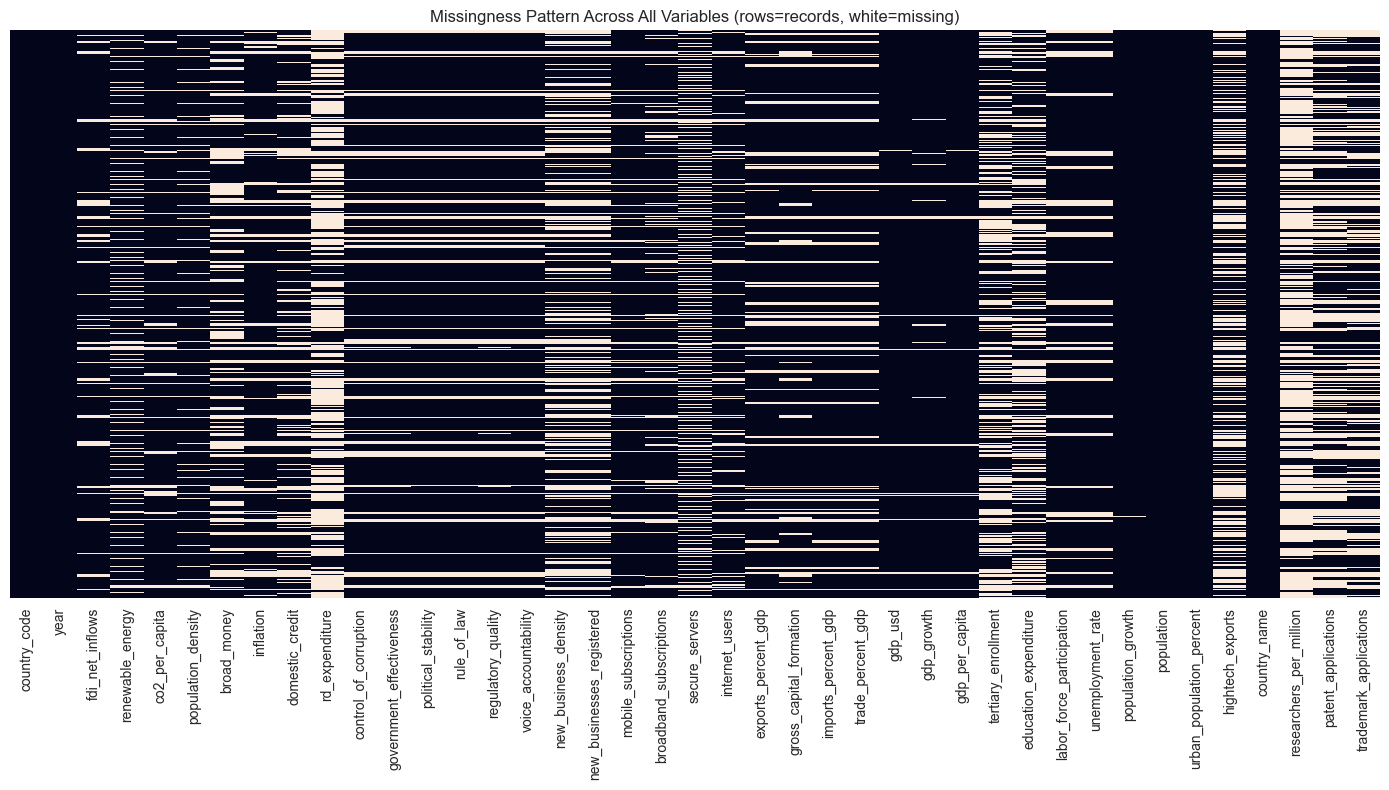

In [12]:
# Visual missingness heatmap across all variables and years (excluding 2005/2025 outlier effect for now)
plt.figure(figsize=(14, 8))
missing_matrix = df.pivot_table(index='year', columns='country_code', values='new_business_density', aggfunc=lambda x: x.isnull().sum())
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missingness Pattern Across All Variables (rows=records, white=missing)')
plt.tight_layout()
plt.show()

## EDA Scoping Decisions
1. **Year range**: Restrict target-based analysis to 2006–2024 (2005 and 2025 are near-fully missing/unreliable for the target and several key predictors).
2. **Missingness type**: Missingness in innovation-related variables (R&D, patents, trademarks, researchers) is structural/MNAR, tied to country reporting capacity — not random. Will inform imputation strategy later (likely no naive mean imputation for these).
3. **Low-capacity countries**: 34 countries have 100% missing target data. Decision on inclusion/exclusion deferred to modeling phase; documented as a known limitation.



In [19]:
df_scope = df[(df['year'] >= 2006) & (df['year'] <= 2024)].copy()

print(df_scope['new_business_density'].describe())
print(f"\nSkewness: {df_scope['new_business_density'].skew():.3f}")
print(f"Kurtosis: {df_scope['new_business_density'].kurtosis():.3f}")

count    2911.000000
mean        5.397670
std        21.107864
min         0.007010
25%         0.556733
50%         1.734372
75%         4.432228
max       377.036154
Name: new_business_density, dtype: float64

Skewness: 11.796
Kurtosis: 154.675


C:\ProgramData\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


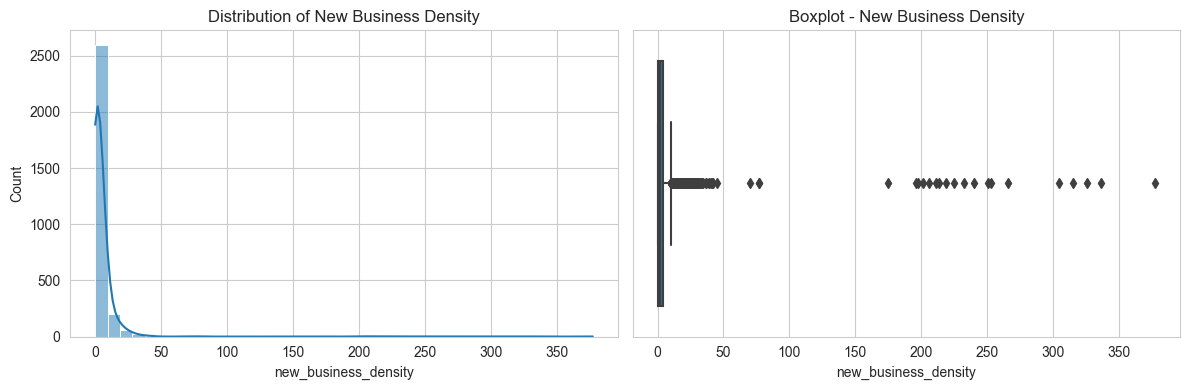

In [20]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_scope['new_business_density'], bins=40, kde=True)
plt.title('Distribution of New Business Density')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_scope['new_business_density'])
plt.title('Boxplot - New Business Density')
plt.tight_layout()
plt.show()

In [21]:
# Which country-years have the highest new_business_density?
top_outliers = df_scope.nlargest(15, 'new_business_density')[['country_name', 'year', 'new_business_density']]
print(top_outliers)

        country_name  year  new_business_density
989   Cayman Islands  2007            377.036154
988   Cayman Islands  2006            336.043583
1000  Cayman Islands  2018            325.316330
1003  Cayman Islands  2021            314.782445
990   Cayman Islands  2008            304.227375
999   Cayman Islands  2017            265.459355
997   Cayman Islands  2015            252.566123
1001  Cayman Islands  2019            250.263600
996   Cayman Islands  2014            240.089884
998   Cayman Islands  2016            232.467181
1002  Cayman Islands  2020            224.490968
1004  Cayman Islands  2022            218.218144
993   Cayman Islands  2011            213.363795
995   Cayman Islands  2013            210.934878
994   Cayman Islands  2012            205.784460


count    2911.000000
mean        1.177121
std         0.912056
min         0.006985
25%         0.442589
50%         1.005902
75%         1.692349
max         5.934990
Name: log_new_business_density, dtype: float64
Skewness after log: 1.190


C:\ProgramData\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


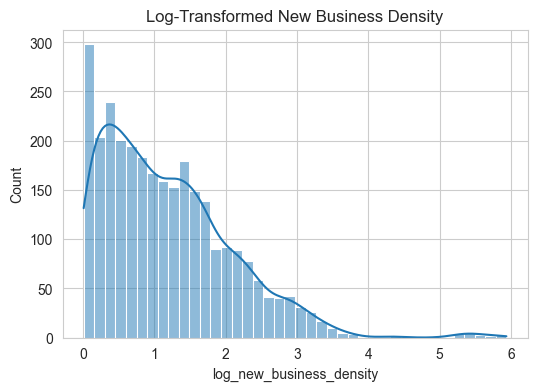

In [22]:
# Log-transform and re-check distribution shape
df_scope['log_new_business_density'] = np.log1p(df_scope['new_business_density'])

print(df_scope['log_new_business_density'].describe())
print(f"Skewness after log: {df_scope['log_new_business_density'].skew():.3f}")

plt.figure(figsize=(6, 4))
sns.histplot(df_scope['log_new_business_density'], bins=40, kde=True)
plt.title('Log-Transformed New Business Density')
plt.show()

In [23]:
print(f"Skewness after log: {df_scope['log_new_business_density'].skew():.3f}")
print(f"Kurtosis after log: {df_scope['log_new_business_density'].kurtosis():.3f}")

Skewness after log: 1.190
Kurtosis after log: 2.398


In [24]:
# Are there other small offshore/tax-haven-like jurisdictions with a similar profile?
# Check top 15 EXCLUDING Cayman Islands
top_excl_cayman = df_scope[df_scope['country_name'] != 'Cayman Islands'].nlargest(15, 'new_business_density')[['country_name', 'year', 'new_business_density']]
print(top_excl_cayman)

              country_name  year  new_business_density
1851           Isle of Man  2008             76.897507
1850           Isle of Man  2007             76.740757
1849           Isle of Man  2006             69.729689
1853           Isle of Man  2010             44.962561
1860           Isle of Man  2017             41.986106
1854           Isle of Man  2011             41.022205
1856           Isle of Man  2013             40.622809
1852           Isle of Man  2009             39.070788
1857           Isle of Man  2014             38.943391
1855           Isle of Man  2012             36.880754
1858           Isle of Man  2015             36.833797
1859           Isle of Man  2016             34.644478
1866           Isle of Man  2023             34.036914
1867           Isle of Man  2024             33.583789
1730  Hong Kong SAR, China  2013             32.717409


In [25]:
# Check skewness across all numeric variables to identify which others need log transforms
numeric_cols = df_scope.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['year', 'log_new_business_density']]

skew_summary = df_scope[numeric_cols].skew().sort_values(ascending=False)
print(skew_summary)

secure_servers               26.156828
broad_money                  18.085742
inflation                    16.262429
new_business_density         11.795736
trademark_applications       11.091431
gdp_usd                      10.005415
patent_applications           9.657848
population                    8.841620
population_density            8.484635
co2_per_capita                7.851468
fdi_net_inflows               5.863316
new_businesses_registered     5.587443
trade_percent_gdp             3.347524
gdp_per_capita                3.151282
exports_percent_gdp           3.107770
imports_percent_gdp           2.856650
hightech_exports              2.161149
domestic_credit               1.578269
rd_expenditure                1.561551
unemployment_rate             1.475810
education_expenditure         1.413699
researchers_per_million       1.397744
population_growth             1.247741
broadband_subscriptions       0.905545
renewable_energy              0.849349
gross_capital_formation  

In [26]:
print(df_scope['inflation'].describe())
print(f"\nNegative inflation (deflation) count: {(df_scope['inflation'] < 0).sum()}")
print(f"\nTop 5 highest inflation events:")
print(df_scope.nlargest(5, 'inflation')[['country_name', 'year', 'inflation']])

count    3494.000000
mean        6.489047
std        18.244165
min       -16.859691
25%         1.589261
50%         3.494758
75%         6.932302
max       557.201817
Name: inflation, dtype: float64

Negative inflation (deflation) count: 251

Top 5 highest inflation events:
       country_name  year   inflation
4551       Zimbabwe  2020  557.201817
3728    South Sudan  2016  379.999586
3544          Sudan  2021  359.093041
4550       Zimbabwe  2019  255.304991
4337  Venezuela, RB  2016  254.948535


In [27]:
# Add log-transformed versions of the most severely skewed variables
df_scope['log_gdp_per_capita'] = np.log1p(df_scope['gdp_per_capita'])
df_scope['log_patent_applications'] = np.log1p(df_scope['patent_applications'])
df_scope['log_trademark_applications'] = np.log1p(df_scope['trademark_applications'])
df_scope['log_fdi_net_inflows'] = np.sign(df_scope['fdi_net_inflows']) * np.log1p(np.abs(df_scope['fdi_net_inflows']))
df_scope['signed_log_inflation'] = np.sign(df_scope['inflation']) * np.log1p(np.abs(df_scope['inflation']))

# Correlation of key predictors with the (log) target variable
corr_cols = ['log_new_business_density', 'log_gdp_per_capita', 'control_of_corruption', 
             'government_effectiveness', 'regulatory_quality', 'rule_of_law', 
             'political_stability', 'voice_accountability', 'log_patent_applications', 
             'log_trademark_applications', 'researchers_per_million', 'log_fdi_net_inflows',
             'signed_log_inflation', 'internet_users', 'tertiary_enrollment', 'unemployment_rate']

corr_matrix = df_scope[corr_cols].corr()
print(corr_matrix['log_new_business_density'].sort_values(ascending=False))

log_new_business_density      1.000000
regulatory_quality            0.665887
log_gdp_per_capita            0.652907
government_effectiveness      0.628375
rule_of_law                   0.618406
control_of_corruption         0.617230
internet_users                0.577760
voice_accountability          0.567179
political_stability           0.559954
tertiary_enrollment           0.448424
researchers_per_million       0.426903
log_patent_applications       0.303550
log_trademark_applications    0.228829
unemployment_rate             0.137589
log_fdi_net_inflows           0.049582
signed_log_inflation         -0.164006
Name: log_new_business_density, dtype: float64


In [28]:
governance_cols = ['regulatory_quality', 'government_effectiveness', 'rule_of_law', 
                    'control_of_corruption', 'political_stability', 'voice_accountability']
print(df_scope[governance_cols].corr())

                          regulatory_quality  government_effectiveness  \
regulatory_quality                  1.000000                  0.939941   
government_effectiveness            0.939941                  1.000000   
rule_of_law                         0.899352                  0.912049   
control_of_corruption               0.886922                  0.925993   
political_stability                 0.660480                  0.709681   
voice_accountability                0.801561                  0.783367   

                          rule_of_law  control_of_corruption  \
regulatory_quality           0.899352               0.886922   
government_effectiveness     0.912049               0.925993   
rule_of_law                  1.000000               0.941164   
control_of_corruption        0.941164               1.000000   
political_stability          0.817154               0.768126   
voice_accountability         0.891837               0.824235   

                          politi

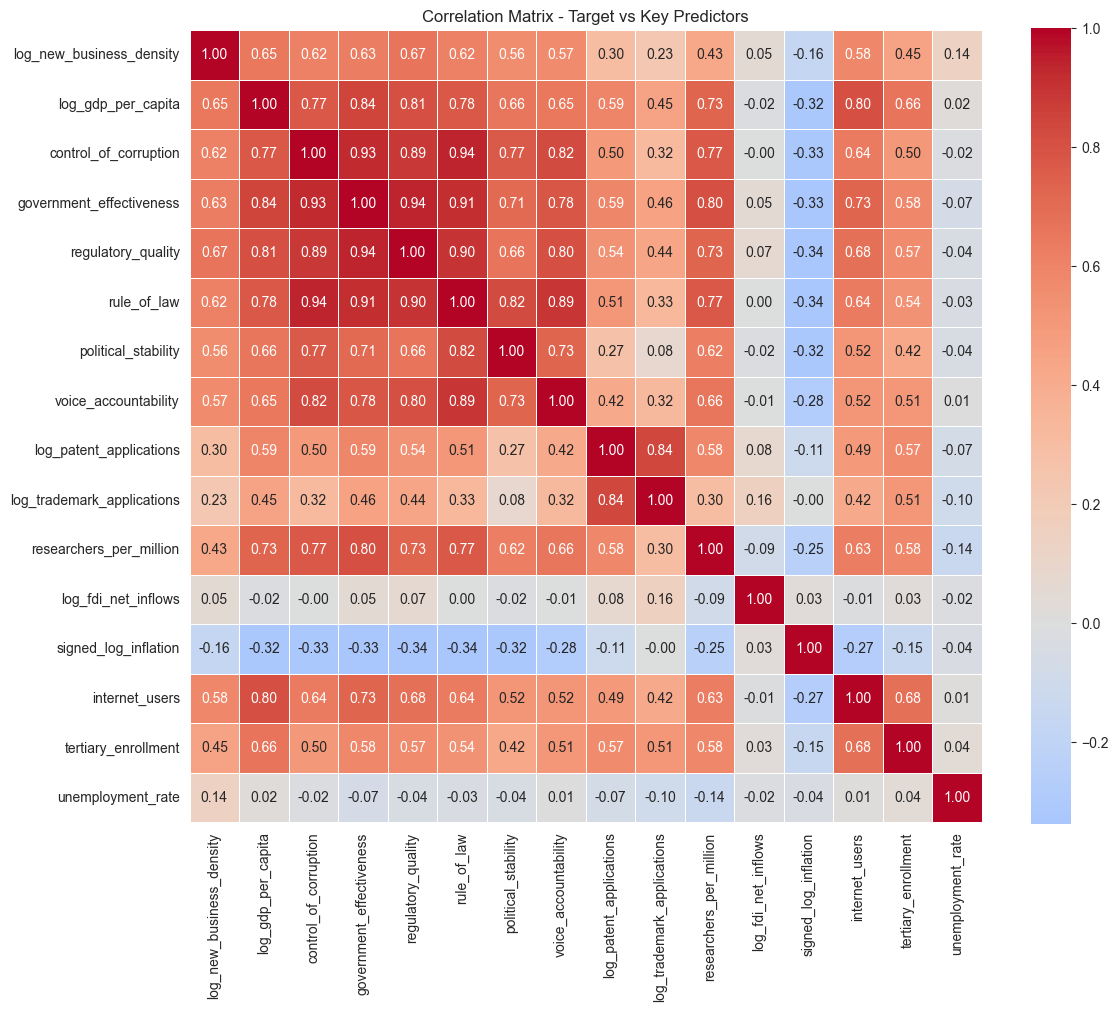

In [29]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix - Target vs Key Predictors')
plt.tight_layout()
plt.show()

In [30]:
print(df_scope.columns.tolist())
# check if any grouping variable already exists (e.g. from World Bank aggregates)

['country_code', 'year', 'fdi_net_inflows', 'renewable_energy', 'co2_per_capita', 'population_density', 'broad_money', 'inflation', 'domestic_credit', 'rd_expenditure', 'control_of_corruption', 'government_effectiveness', 'political_stability', 'rule_of_law', 'regulatory_quality', 'voice_accountability', 'new_business_density', 'new_businesses_registered', 'mobile_subscriptions', 'broadband_subscriptions', 'secure_servers', 'internet_users', 'exports_percent_gdp', 'gross_capital_formation', 'imports_percent_gdp', 'trade_percent_gdp', 'gdp_usd', 'gdp_growth', 'gdp_per_capita', 'tertiary_enrollment', 'education_expenditure', 'labor_force_participation', 'unemployment_rate', 'population_growth', 'population', 'urban_population_percent', 'hightech_exports', 'country_name', 'researchers_per_million', 'patent_applications', 'trademark_applications', 'log_new_business_density', 'log_gdp_per_capita', 'log_patent_applications', 'log_trademark_applications', 'log_fdi_net_inflows', 'signed_log_in

In [31]:
import requests

url = "https://api.worldbank.org/v2/country?format=json&per_page=300"
response = requests.get(url)
data = response.json()

countries_meta = pd.DataFrame(data[1])
countries_meta = countries_meta[['id', 'region', 'incomeLevel']]
countries_meta['region'] = countries_meta['region'].apply(lambda x: x['value'])
countries_meta['incomeLevel'] = countries_meta['incomeLevel'].apply(lambda x: x['value'])
countries_meta.columns = ['country_code', 'region', 'income_group']

# Drop aggregate "regions" that aren't real countries (World Bank includes these in this endpoint)
countries_meta = countries_meta[countries_meta['region'] != 'Aggregates']

print(countries_meta.shape)
countries_meta.head(10)

(217, 3)


,country_code,region,income_group
0,ABW,Latin America & Caribbean,High income
2,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income
5,AGO,Sub-Saharan Africa,Lower middle income
6,ALB,Europe & Central Asia,Upper middle income
7,AND,Europe & Central Asia,High income
9,ARE,"Middle East, North Africa, Afghanistan & Pakistan",High income
10,ARG,Latin America & Caribbean,Upper middle income
11,ARM,Europe & Central Asia,Upper middle income
12,ASM,East Asia & Pacific,High income
13,ATG,Latin America & Caribbean,High income


In [32]:
# Merge into df_scope
df_scope = df_scope.merge(countries_meta, on='country_code', how='left')
print(df_scope.shape)
print(f"\nUnmatched country_codes (no income/region assigned): {df_scope['income_group'].isnull().sum()} rows")
print(df_scope[df_scope['income_group'].isnull()]['country_name'].unique())

(4123, 49)

Unmatched country_codes (no income/region assigned): 0 rows
[]


In [33]:
income_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']

income_summary = df_scope.groupby('income_group')['new_business_density'].agg(['count', 'mean', 'median', 'std']).reindex(income_order)
print(income_summary)

                     count       mean    median        std
income_group                                              
Low income             271   0.407292  0.192075   0.518525
Lower middle income    652   1.091068  0.543482   1.617649
Upper middle income    918   2.941685  1.659438   3.573821
High income           1070  11.392895  4.319701  33.785231


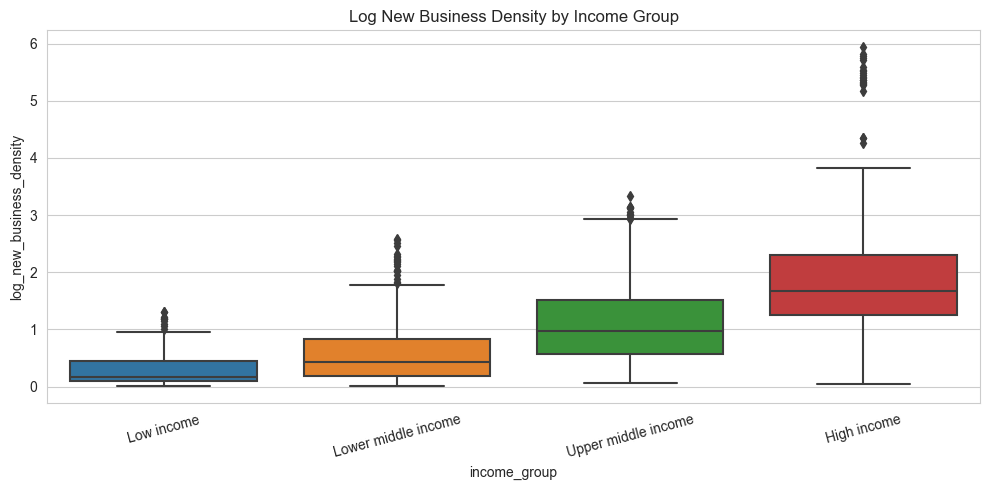

In [34]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_scope, x='income_group', y='log_new_business_density', order=income_order)
plt.title('Log New Business Density by Income Group')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [35]:
region_summary = df_scope.groupby('region')['new_business_density'].agg(['count', 'mean', 'median']).sort_values('median', ascending=False)
print(region_summary)

                                                   count       mean    median
region                                                                       
North America                                          6   3.698299  3.990438
Europe & Central Asia                                902   5.876817  3.817088
Latin America & Caribbean                            493  12.887081  2.535458
East Asia & Pacific                                  438   4.468730  1.325726
Middle East, North Africa, Afghanistan & Pakistan    303   2.038106  1.140319
Sub-Saharan Africa                                   671   2.042714  0.741517
South Asia                                            98   0.925478  0.172127


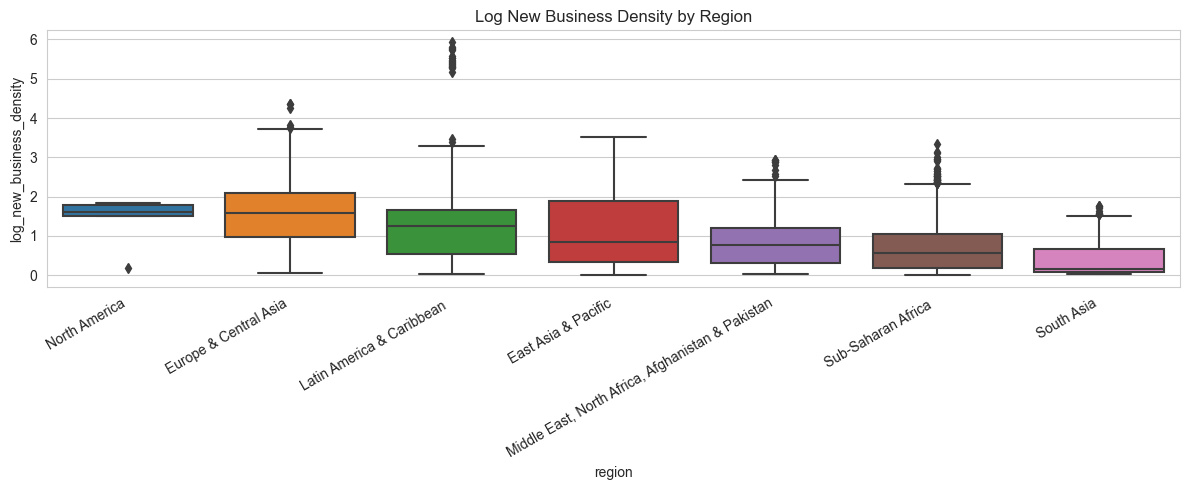

In [36]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_scope, x='region', y='log_new_business_density', 
            order=df_scope.groupby('region')['log_new_business_density'].median().sort_values(ascending=False).index)
plt.title('Log New Business Density by Region')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [37]:
offshore_centers = ['Cayman Islands', 'Isle of Man', 'Bermuda', 'British Virgin Islands', 
                     'Gibraltar', 'Guernsey', 'Jersey', 'Channel Islands', 'Monaco', 'Curacao']

df_scope['is_offshore_center'] = df_scope['country_name'].isin(offshore_centers)

print(df_scope['is_offshore_center'].value_counts())
print(f"\nOffshore centers present with target data: {df_scope[df_scope['is_offshore_center']]['country_name'].unique()}")

is_offshore_center
False    3971
True      152
Name: count, dtype: int64

Offshore centers present with target data: ['Bermuda' 'Channel Islands' 'Curacao' 'Cayman Islands' 'Gibraltar'
 'Isle of Man' 'Monaco' 'British Virgin Islands']


In [38]:
income_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']

print("WITH offshore centers:")
print(df_scope.groupby('income_group')['new_business_density'].agg(['mean', 'median']).reindex(income_order))

print("\nWITHOUT offshore centers:")
print(df_scope[~df_scope['is_offshore_center']].groupby('income_group')['new_business_density'].agg(['mean', 'median']).reindex(income_order))

WITH offshore centers:
                          mean    median
income_group                            
Low income            0.407292  0.192075
Lower middle income   1.091068  0.543482
Upper middle income   2.941685  1.659438
High income          11.392895  4.319701

WITHOUT offshore centers:
                         mean    median
income_group                           
Low income           0.407292  0.192075
Lower middle income  1.091068  0.543482
Upper middle income  2.941685  1.659438
High income          6.443092  4.200233


In [39]:
print("Latin America & Caribbean — WITH vs WITHOUT offshore:")
print("With:", df_scope[df_scope['region']=='Latin America & Caribbean']['new_business_density'].mean())
print("Without:", df_scope[(df_scope['region']=='Latin America & Caribbean') & (~df_scope['is_offshore_center'])]['new_business_density'].mean())

Latin America & Caribbean — WITH vs WITHOUT offshore:
With: nan
Without: nan


In [40]:
# Check exact region string values
print(df_scope['region'].unique())

['Latin America & Caribbean '
 'Middle East, North Africa, Afghanistan & Pakistan' 'Sub-Saharan Africa '
 'Europe & Central Asia' 'East Asia & Pacific' 'South Asia'
 'North America']


In [41]:
# Also confirm exact string match
print([r for r in df_scope['region'].unique() if 'Latin' in r])

['Latin America & Caribbean ']


In [42]:
df_scope['region'] = df_scope['region'].str.strip()

print("Latin America & Caribbean — WITH vs WITHOUT offshore:")
print("With:", df_scope[df_scope['region']=='Latin America & Caribbean']['new_business_density'].mean())
print("Without:", df_scope[(df_scope['region']=='Latin America & Caribbean') & (~df_scope['is_offshore_center'])]['new_business_density'].mean())

Latin America & Caribbean — WITH vs WITHOUT offshore:
With: 12.887081195616652
Without: 3.4051386974279563


## EDA Summary

**Dataset**: 217 countries × 21 years (2005–2025), 41 variables, World Bank + UNESCO + WIPO sources.

**Scoping decisions**:
- Restricted analysis to 2006–2024 (2005 and 2025 near-fully missing for target and several predictors)
- Target variable: `new_business_density` (new registrations per 1,000 working-age population), chosen over raw registrations for cross-country comparability
- Missingness is structural (MNAR), tied to country statistical reporting capacity — not random. Innovation-related variables (R&D, patents, researchers) are sparsest.
- 34 countries have 100% missing target data (mostly microstates and low-capacity states)
- 8 offshore financial centers (Cayman Islands, Isle of Man, etc.) flagged via `is_offshore_center` — they distort mean-based statistics severely (e.g. Latin America & Caribbean regional mean: 12.9 → 3.4 excluding them) but are kept in the dataset with a flag rather than dropped

**Key findings**:
- Target variable is extremely right-skewed (skew 11.8 → 1.19 after log transform)
- Strong positive correlation between governance quality (regulatory quality, government effectiveness, rule of law, control of corruption) and new business density (r ≈ 0.6–0.67)
- Severe multicollinearity among the 6 WGI governance indicators (r = 0.66–0.94) — requires dimensionality reduction (composite index or PCA) before modeling
- GDP per capita strongly correlated with target (r = 0.65) — consistent with a broader "development cluster" effect (wealth, governance, connectivity move together)
- Patent/trademark applications weakly correlated with target (r = 0.23–0.30) — innovation output ≠ new business formation, a nuanced finding
- Clean monotonic relationship between income group and business density (Low → High income)



In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

governance_cols = ['regulatory_quality', 'government_effectiveness', 'rule_of_law', 
                    'control_of_corruption', 'political_stability', 'voice_accountability']

# PCA requires no missing values -- use listwise deletion for this subset only
gov_data = df_scope[governance_cols].dropna()
print(f"Rows available for PCA: {len(gov_data)} / {len(df_scope)}")

scaler = StandardScaler()
gov_scaled = scaler.fit_transform(gov_data)

pca = PCA()
pca.fit(gov_scaled)

print("\nExplained variance ratio per component:")
print(pca.explained_variance_ratio_)
print("\nCumulative variance explained:")
print(np.cumsum(pca.explained_variance_ratio_))

Rows available for PCA: 3641 / 4123

Explained variance ratio per component:
[0.86254534 0.06688283 0.03962083 0.0163117  0.00810653 0.00653277]

Cumulative variance explained:
[0.86254534 0.92942817 0.969049   0.9853607  0.99346723 1.        ]


In [44]:
loadings = pd.DataFrame(
    pca.components_[0], 
    index=governance_cols, 
    columns=['PC1_loading']
).sort_values('PC1_loading', ascending=False)
print(loadings)

                          PC1_loading
political_stability         -0.367059
voice_accountability        -0.396649
regulatory_quality          -0.410912
government_effectiveness    -0.417333
control_of_corruption       -0.422908
rule_of_law                 -0.431359


In [45]:
# Flip sign so higher = better governance (more intuitive)
df_scope['governance_index'] = np.nan
df_scope.loc[gov_data.index, 'governance_index'] = -pca.transform(gov_scaled)[:, 0]

print(df_scope['governance_index'].describe())
print(f"\nCorrelation with target: {df_scope[['governance_index', 'log_new_business_density']].corr().iloc[0,1]:.3f}")

count    3.641000e+03
mean    -1.561203e-17
std      2.275235e+00
min     -5.293362e+00
25%     -1.665554e+00
50%     -3.171175e-01
75%      1.646638e+00
max      5.044396e+00
Name: governance_index, dtype: float64

Correlation with target: 0.656


## Governance Index (PCA)

Reduced 6 highly collinear WGI governance indicators (pairwise r = 0.66–0.94) into a single 
composite `governance_index` via PCA. PC1 explains 86.3% of variance, all loadings same sign 
(no dominant variable), sign-flipped so higher = better governance.

Correlation with log_new_business_density: 0.656 — nearly matches the best individual raw 
variable (regulatory_quality, r=0.667), confirming the composite captures the relationship 
with minimal information loss while eliminating multicollinearity for modeling.

**3641/4123 rows have a valid governance_index** (482 rows dropped due to missing WGI data 
in at least one of the 6 source variables) — this constraint carries forward into modeling.

In [46]:
countries_no_target = df_scope.groupby('country_name')['new_business_density'].apply(lambda x: x.isnull().all())
countries_to_exclude = countries_no_target[countries_no_target].index.tolist()

df_model_ready = df_scope[~df_scope['country_name'].isin(countries_to_exclude)].copy()
print(f"Countries excluded: {len(countries_to_exclude)}")
print(f"Rows before: {len(df_scope)}, after: {len(df_model_ready)}")

Countries excluded: 34
Rows before: 4123, after: 3477


## Final Dataset for Modeling
- `df_model_ready`: excludes 34 countries with 100% missing target (zero information for supervised learning)
- Remaining moderately-skewed variables (skew 1–5) left untransformed; transformation decision deferred to modeling notebook based on model choice (tree-based vs. linear)
- Saved as input to `06_modeling.ipynb`

In [48]:
df_model_ready.to_csv('../data/master/eda_output.csv', index=False)
print("Saved:", df_model_ready.shape)

Saved: (3477, 51)
